In [2]:
import pandas as pd 
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt 
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm
import pmdarima as pm
import matplotlib.dates as mdates
import matplotlib as mpl
from cycler import cycler

mpl.rcParams['axes.prop_cycle'] = cycler(color=['teal', 'maroon', 'steelblue', '#3EB489', '#6B8E23'])

In [3]:
df = pd.read_csv('/home/uplong/Documents/DSU-analytics-comp-2026/data/grouped_by_year_month_day.csv', parse_dates=['Date'])
df = df.drop(columns=['unique_entry_per_day', 'total_admittances'])
df = df.set_index('Date')
df

,total_encounters
Date,
2018-01-01,501
2018-01-02,436
2018-01-03,420
2018-01-04,410
2018-01-05,408
...,...
2025-08-27,472
2025-08-28,498
2025-08-29,548


In [4]:
adfuller(df.total_encounters)

(np.float64(-2.818950913837888),
 np.float64(0.05561733920992404),
 27,
 2772,
 {'1%': np.float64(-3.432711243107154),
  '5%': np.float64(-2.8625832296637324),
  '10%': np.float64(-2.5673253439205497)},
 np.float64(26399.36398525593))

In [5]:
diff = np.diff(df.total_encounters, n=1)

adfuller(diff)

(np.float64(-15.155640286609916),
 np.float64(6.7008105236337105e-28),
 26,
 2772,
 {'1%': np.float64(-3.432711243107154),
  '5%': np.float64(-2.8625832296637324),
  '10%': np.float64(-2.5673253439205497)},
 np.float64(26396.88271229819))

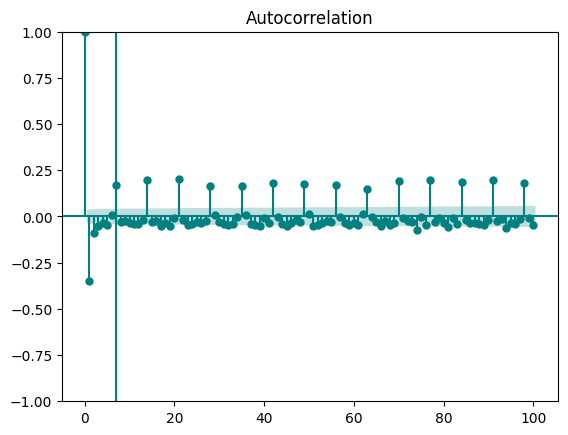

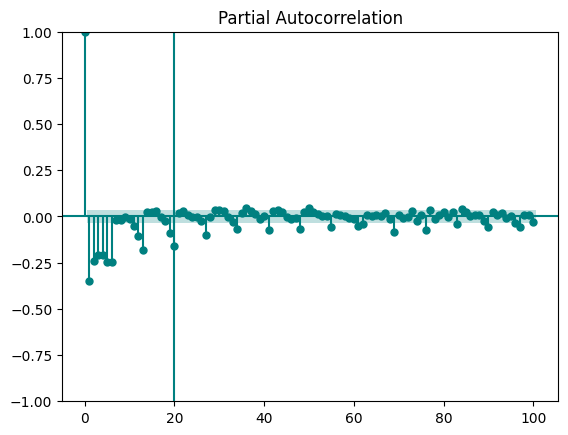

In [6]:
plot_acf(diff, lags=100)
plt.axvline(7)

plot_pacf(diff, lags=100)
plt.axvline(20)
plt.show()

In [7]:
train = df.loc['2023':'2024']
test = df.loc['2025']

In [8]:
model = pm.auto_arima(
    y=train,
    seasonal=True,
    m=7,
    error_action='ignore',
    suppress_warnings=True,
)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                       SARIMAX Results                                        
==============================================================================================
Dep. Variable:                                      y   No. Observations:                  731
Model:             SARIMAX(1, 1, 3)x(0, 0, [1, 2], 7)   Log Likelihood               -3499.921
Date:                                Tue, 10 Feb 2026   AIC                           7013.843
Time:                                        16:59:50   BIC                           7045.994
Sample:                                    01-01-2023   HQIC                          7026.247
                                         - 12-31-2024                                         
Covariance Type:                                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7946      0.141      5.632      0.000       0.518       1.071
ma.L1         -1.5567      0.148    -10.523      0.000      -1.847      -1.267
ma.L2          0.4904      0.117      4.175      0.000       0.260       0.721
ma.L3          0.0720      0.059      1.216      0.224      -0.044       0.188
ma.S.L7        0.1483      0.039      3.793      0.000       0.072       0.225
ma.S.L14       0.1550      0.040      3.835      0.000       0.076       0.234
sigma2       851.8898     39.242     21.708      0.000     774.976     928.803
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                25.97
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               0.90   Skew:                            -0.30
Prob(H) (two-sided):                  0.39   Kurtosis:                         3.71
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

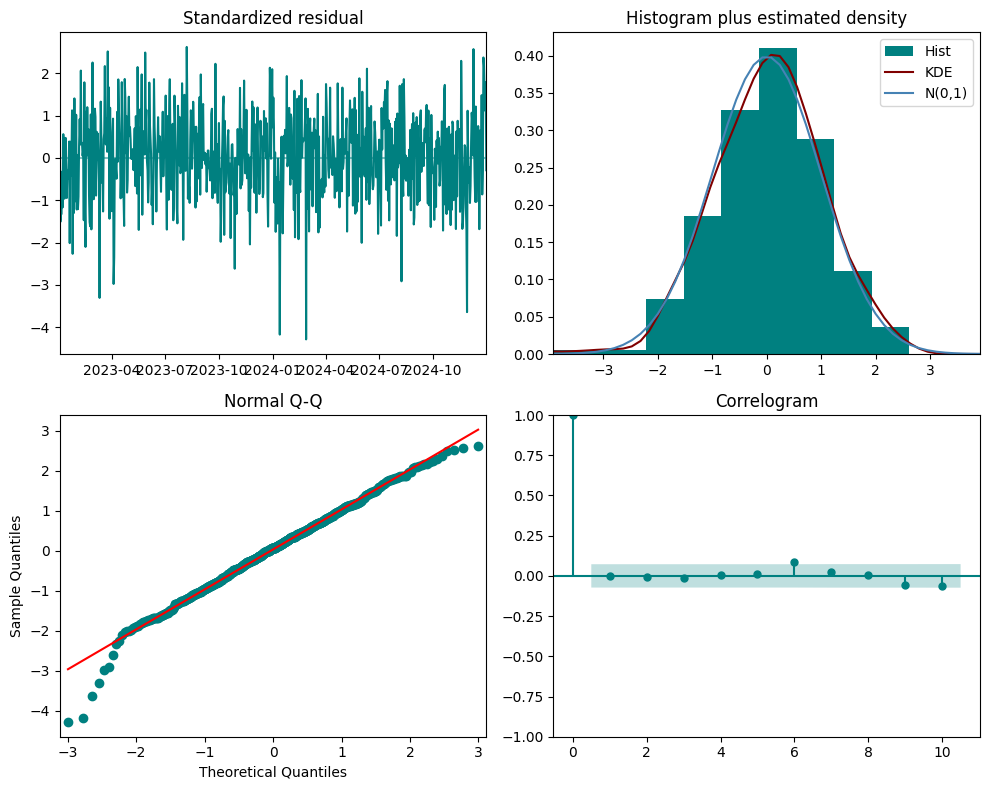

In [9]:
model.plot_diagnostics(figsize=(10,8))
plt.tight_layout()
plt.show()

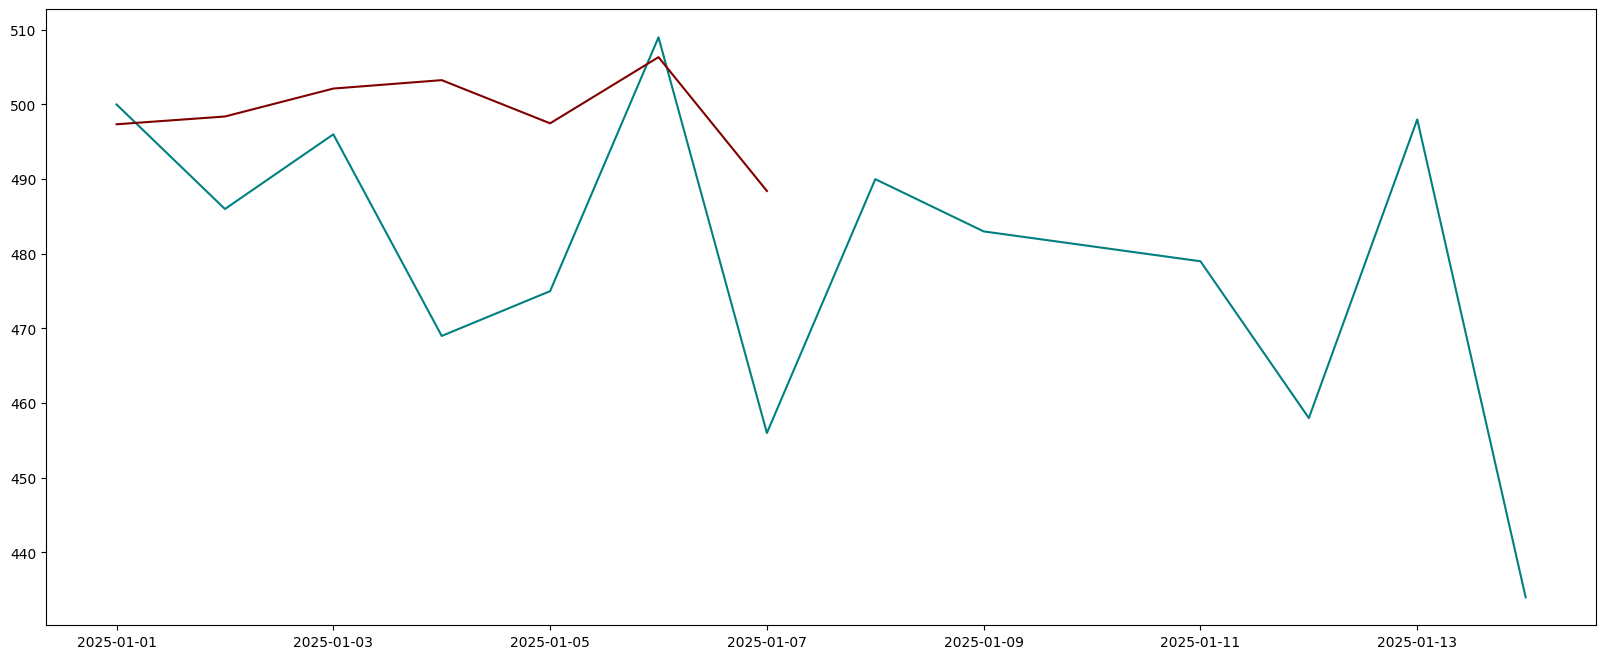

In [12]:
# plt.plot(train)
plt.figure(figsize=(20,8))
plt.plot(test[:14])
plt.plot(model.predict(7))
# plt.xlim(20000)
plt.show()